# Part C: Hessian Spectrum Analysis for SAM Generalisation

Our broader project asks whether geometry-aware interventions can improve robustness under distribution shift. The original GNN hypothesis is that over-squashing compresses long-range information through topological bottlenecks and may be mitigated by curvature-aware graph rewiring. This notebook studies the same style of geometric question in the SAM setting: **does a curvature-aware optimizer improve out-of-distribution (OOD) generalisation by changing the local geometry of the learned minimum?**

In this research, Part C treats flatness and effective dimensionality as related Hessian-based diagnostics rather than fully separate explanations. Since trace, top eigenvalues, spectrum concentration, and MacKay-style $N_{\text{eff}}(z)$ are all derived from the local Hessian spectrum, we separate the analysis into three measurable aspects:

1. **Curvature magnitude / flatness**: whether SAM reduces the overall scale of local Hessian curvature, measured by Hessian trace, the largest eigenvalue, and the sum of the top-k eigenvalues.
2. **Sharp-direction sensitivity**: whether SAM reduces the dominance of the sharpest directions, measured by the top-1 and top-5 fractions of top-k curvature mass.
3. **Effective dimensionality diagnostic**: whether the MacKay / Maddox $N_{\text{eff}}(z)$ top-k approximation also changes, treated as auxiliary evidence because it is sensitive to $z$ and does not represent the full Hessian.

The main expected conclusion is therefore more precise than "SAM lowers effective dimensionality": if SAM improves OOD accuracy while lowering trace/top eigenvalues/top-k curvature mass, then Part C supports a **curvature-magnitude explanation** of SAM's OOD advantage. If $N_{\text{eff}}(z)$ also decreases consistently, that can be discussed as secondary evidence, not the core claim.

Key literature used in this notebook:

- [Foret et al. (2021)](https://arxiv.org/abs/2010.01412): SAM explicitly minimizes neighborhood sharpness to improve generalisation.
- [Ghorbani et al. (2019)](https://proceedings.mlr.press/v97/ghorbani19b.html): Hessian eigenvalues characterize local curvature, and Hessian spectra are useful for analysing smoothness, sharpness, and optimization.
- [Maddox et al. (2020)](https://arxiv.org/abs/2003.02139): MacKay-style effective dimensionality measures data-determined parameter directions and should not be confused with generic spectrum-spread metrics.
- [Eigen-SAM / NeurIPS 2024](https://proceedings.neurips.cc/paper_files/paper/2024/hash/0845e3f7447ff9e36a26033bb7334674-Abstract-Conference.html): the largest Hessian eigenvalue is widely used as a sharpness proxy because it represents maximal local curvature.

## 1. Mount Drive and Setup

In [17]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os, sys
from pathlib import Path

if 'google.colab' in sys.modules:
    PROJECT_ROOT = Path('/content/drive/MyDrive/Assignment2_SAM')
else:
    cwd = Path.cwd()
    if cwd.name == 'part_c' and (cwd.parent / 'config.py').exists():
        PROJECT_ROOT = cwd.parent
    elif (cwd / 'config.py').exists():
        PROJECT_ROOT = cwd
    else:
        PROJECT_ROOT = cwd

PROJECT_ROOT = PROJECT_ROOT.resolve()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PART_C_DIR = PROJECT_ROOT / 'part_c'
os.makedirs(PART_C_DIR, exist_ok=True)

print('Working directory:', os.getcwd())
print('Part C output dir:', PART_C_DIR)

Working directory: /content/drive/MyDrive/Assignment2_SAM
Part C output dir: /content/drive/MyDrive/Assignment2_SAM/part_c


In [19]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')   # non-interactive backend — prevents kernel crashes
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import display, Image as IPImage

from config import MODEL_NAME, SEED
from data import get_id_test_loader
from models import get_model

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Model:', MODEL_NAME)

Device: cuda
Model: resnet18


## 2. Load Updated Part A Checkpoints

Part A saves separate checkpoints for different selection criteria. We use `best_ood` because the core question is OOD generalisation. The Hessian is evaluated on ID test batches (the natural local geometry of the learned solution), not on OOD data, which would conflate distribution shift with landscape geometry.

In [20]:
CHECKPOINT_TAG = 'best_ood'
OUT_PREFIX = CHECKPOINT_TAG  # prefix saved figures and CSV files

ckpt_dir = PROJECT_ROOT / 'checkpoints'
sgd_ckpt_path = ckpt_dir / f'sgd_resnet18_cifar10_{CHECKPOINT_TAG}.pt'
sam_ckpt_path = ckpt_dir / f'sam_resnet18_cifar10_{CHECKPOINT_TAG}.pt'

print('Checkpoint tag:', CHECKPOINT_TAG)
print('SGD exists:', sgd_ckpt_path.exists())
print('SAM exists:', sam_ckpt_path.exists())

if not sgd_ckpt_path.exists() or not sam_ckpt_path.exists():
    available = sorted(p.name for p in ckpt_dir.glob('*.pt'))
    raise FileNotFoundError(
        f'Missing checkpoint for tag {CHECKPOINT_TAG!r}. Available: {available}'
    )

sgd_ckpt = torch.load(sgd_ckpt_path, map_location=device)
sam_ckpt = torch.load(sam_ckpt_path, map_location=device)

print('SGD keys:', list(sgd_ckpt.keys()))
print('SAM keys:', list(sam_ckpt.keys()))

Checkpoint tag: best_ood
SGD exists: True
SAM exists: True
SGD keys: ['optimizer_name', 'checkpoint_type', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'metrics']
SAM keys: ['optimizer_name', 'checkpoint_type', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'metrics']


In [21]:
sgd_model = get_model(MODEL_NAME).to(device)
sam_model = get_model(MODEL_NAME).to(device)

sgd_model.load_state_dict(sgd_ckpt['model_state_dict'])
sam_model.load_state_dict(sam_ckpt['model_state_dict'])
sgd_model.eval()
sam_model.eval()

def get_metrics(ckpt):
    """Part A v1 used final_metrics; updated checkpoints use metrics."""
    return ckpt.get('metrics', ckpt.get('final_metrics', {}))

sgd_metrics = get_metrics(sgd_ckpt)
sam_metrics = get_metrics(sam_ckpt)

metrics_df = pd.DataFrame([
    {'model': 'SGD', 'checkpoint': CHECKPOINT_TAG, **sgd_metrics},
    {'model': 'SAM', 'checkpoint': CHECKPOINT_TAG, **sam_metrics},
])

summary_cols = [
    'model', 'checkpoint', 'epoch', 'id_acc', 'ood_noise_acc',
    'ood_blur_acc', 'ood_brightness_acc', 'avg_ood_acc', 'id_ood_acc_drop'
]
summary_cols = [c for c in summary_cols if c in metrics_df.columns]
print(metrics_df[summary_cols].to_string(index=False))

# Per-corruption OOD summary for reference in Section 9
print('\nPer-corruption OOD accuracy difference (SAM - SGD):')
for col in ['ood_noise_acc', 'ood_blur_acc', 'ood_brightness_acc', 'avg_ood_acc']:
    if col in metrics_df.columns:
        sgd_val = metrics_df[metrics_df['model']=='SGD'][col].values[0]
        sam_val = metrics_df[metrics_df['model']=='SAM'][col].values[0]
        print(f'  {col}: SGD={sgd_val:.4f}  SAM={sam_val:.4f}  diff={sam_val-sgd_val:+.4f}')

model checkpoint  epoch  id_acc  ood_noise_acc  ood_blur_acc  ood_brightness_acc  avg_ood_acc  id_ood_acc_drop
  SGD   best_ood     41  0.8477         0.2246        0.6391              0.8066     0.556767         0.290933
  SAM   best_ood     17  0.8622         0.2994        0.6587              0.8169     0.591667         0.270533

Per-corruption OOD accuracy difference (SAM - SGD):
  ood_noise_acc: SGD=0.2246  SAM=0.2994  diff=+0.0748
  ood_blur_acc: SGD=0.6391  SAM=0.6587  diff=+0.0196
  ood_brightness_acc: SGD=0.8066  SAM=0.8169  diff=+0.0103
  avg_ood_acc: SGD=0.5568  SAM=0.5917  diff=+0.0349


## 3. Fixed Analysis Batches

Same strategy as Part B: use fixed ID test batches so the SGD vs SAM
comparison is stable and reproducible across runs.

In [22]:
id_loader = get_id_test_loader()
criterion = nn.CrossEntropyLoss()

# Reproducibility for fixed batch selection and downstream stochastic Hessian estimates.
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NUM_BATCHES = 5
fixed_batches = []
for i, (inputs, targets) in enumerate(id_loader):
    if i >= NUM_BATCHES:
        break
    fixed_batches.append((inputs.to(device), targets.to(device)))

print(f'Using {len(fixed_batches)} batches of size {fixed_batches[0][0].shape[0]}')

Using 5 batches of size 128


## 4. What property of SAM are we testing?

We are not simply testing whether SAM is better than SGD. Part A already
measures performance. Part B measures a coarser, first-order sharpness proxy
under gradient-direction perturbations. Part C asks a more specific Hessian
question:

**When SAM finds a flatter-looking solution, is the difference mainly lower
curvature magnitude and reduced sharp-direction sensitivity?**

We therefore report two primary groups of quantities from the Hessian spectrum:

1. **Magnitude / flatness**: Hessian trace, top-1 eigenvalue, and sum of top-k eigenvalues.
2. **Sharp-direction dominance**: top-1 fraction and top-5 fraction of the top-k eigenvalue mass.

We also report MacKay / Maddox $N_{\text{eff}}(z)$ as an auxiliary diagnostic,
but we do not use spectral effective rank as evidence for effective dimensionality.
Generic spectrum spread is not the same thing as MacKay-style effective
dimensionality.

## 5. Hessian Trace via Hutchinson's Estimator

Computing the full Hessian matrix is infeasible for large networks (ResNet18
has about 11M parameters, making $H$ an $11M \times 11M$ matrix). Instead,
we use Hutchinson's estimator:

$$\text{tr}(H) \approx \frac{1}{m} \sum_{i=1}^{m} v_i^T H v_i$$

where $v_i$ are random Rademacher vectors (each element independently
$\pm 1$ with equal probability) and $m = 20$.

This works because $\mathbb{E}[v^T H v] = \text{tr}(H)$ for any isotropic
random vector $v$. The Hessian-vector product $Hv$ is computed via double
backpropagation without forming $H$ explicitly.

**Interpretation:** a lower trace means lower total curvature around the
solution. It is a flatness / curvature-magnitude measure. By itself, it does
**not** prove lower effective dimensionality, because the same number of
directions could simply have smaller eigenvalues.

*Sources: [Hutchinson (1989)](https://doi.org/10.1080/03610918908812806);
[Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145), Section III-B;
[Foret et al., SAM (2021)](https://arxiv.org/abs/2010.01412).*

In [23]:
def hessian_trace_hutchinson(model, inputs, targets, criterion, num_samples=20, seed=None):
    """
    Estimate Hessian trace via Hutchinson's method.
    Source: Hutchinson (1989); Yao et al. PyHessian (2020) Section III-B.
    """
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    grads = torch.autograd.grad(loss, params, create_graph=True, retain_graph=True)
    estimates = []
    for _ in range(num_samples):
        v = [torch.randint_like(p, 0, 2).float() * 2 - 1 for p in params]
        Hv = torch.autograd.grad(grads, params, grad_outputs=v,
                                  retain_graph=True, allow_unused=True)
        vHv = sum((vi * hvi).sum().item()
                  for vi, hvi in zip(v, Hv) if hvi is not None)
        estimates.append(vHv)
    return float(np.mean(estimates)), float(np.std(estimates))

print('Hutchinson trace estimator defined.')

Hutchinson trace estimator defined.


In [24]:
trace_results = []

# Fix random seeds before stochastic Hutchinson trace estimates.
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

for batch_idx, (inputs, targets) in enumerate(fixed_batches):
    print(f'Batch {batch_idx+1}/{len(fixed_batches)}...')
    for model_idx, (model_name, model) in enumerate([('SGD', sgd_model), ('SAM', sam_model)]):
        trace_seed = SEED + 1000 * batch_idx + model_idx
        mean, std = hessian_trace_hutchinson(
            model, inputs, targets, criterion, seed=trace_seed
        )
        trace_results.append({'model': model_name, 'batch': batch_idx,
                               'trace_mean': mean, 'trace_std': std})
        print(f'  {model_name}: {mean:.2f} +/- {std:.2f}')

trace_df = pd.DataFrame(trace_results)
print('\nTrace summary:')
print(trace_df.groupby('model')['trace_mean'].agg(['mean', 'std']))

Batch 1/5...
  SGD: 821.64 +/- 284.97
  SAM: 457.08 +/- 146.27
Batch 2/5...
  SGD: 954.19 +/- 405.74
  SAM: 542.43 +/- 146.95
Batch 3/5...
  SGD: 748.11 +/- 402.94
  SAM: 459.80 +/- 155.53
Batch 4/5...
  SGD: 899.52 +/- 368.31
  SAM: 496.19 +/- 157.56
Batch 5/5...
  SGD: 813.47 +/- 268.28
  SAM: 407.26 +/- 176.30

Trace summary:
             mean        std
model                       
SAM    472.550986  50.266996
SGD    847.388593  80.303799


## 6. Top-k Hessian Eigenvalues via Power Iteration

We compute the top-$k$ Hessian eigenvalues using power iteration with
deflation, following
[Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145),
Section III-A and Appendix Algorithm 2.

The Hessian-vector product is computed via double backpropagation:

$$\frac{\partial g_\theta^T v}{\partial \theta} = Hv$$

The top-$k$ eigenvalues are found by successive deflated power iteration:

$$v \leftarrow \frac{Hv - \sum_{j<i} \lambda_j (v_j^T v) v_j}
{\| Hv - \sum_{j<i} \lambda_j (v_j^T v) v_j \|}$$

We compute only the top $k=20$ eigenvalues. This is justified because neural
network Hessians are approximately low-rank in practice
([Yao et al., 2020](https://arxiv.org/abs/1912.07145), Section IV).
These eigenvalues are used to compute effective dimensionality in Section 7.

In [25]:
def hvp(loss, params, v):
    grads = torch.autograd.grad(loss, params, create_graph=True, retain_graph=True)
    Hv = torch.autograd.grad(
        grads, params, grad_outputs=v,
        retain_graph=True, allow_unused=True
    )
    return [h if h is not None else torch.zeros_like(p) for h, p in zip(Hv, params)]


def get_top_k_eigenvalues(model, inputs, targets, criterion, k=20, n_iters=30):
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    eigenvalues, eigenvectors = [], []

    for i in range(k):
        v = [torch.randn_like(p) for p in params]
        v_norm = sum((vi**2).sum() for vi in v).sqrt()
        v = [vi / v_norm for vi in v]

        # Orthogonalize against previous eigenvectors
        for prev in eigenvectors:
            dot = sum((vi * pi).sum() for vi, pi in zip(v, prev))
            v = [vi - dot * pi for vi, pi in zip(v, prev)]
            n = sum((vi**2).sum() for vi in v).sqrt()
            v = [vi / (n + 1e-8) for vi in v]

        lam = None
        for _ in range(n_iters):
            Hv = hvp(loss, params, v)
            # Deflation: subtract known eigenvalue contributions
            for prev_lam, prev in zip(eigenvalues, eigenvectors):
                dot = sum((vi * pi).sum() for vi, pi in zip(v, prev))
                Hv = [h - prev_lam * dot * pi for h, pi in zip(Hv, prev)]
            lam = sum((vi * h).sum().item() for vi, h in zip(v, Hv))
            n = sum((h**2).sum() for h in Hv).sqrt()
            v = [h / (n + 1e-8) for h in Hv]

        eigenvalues.append(lam)
        eigenvectors.append(v)
        if (i + 1) % 5 == 0:
            print(f'  eigenvalue {i+1}/{k}: {lam:.4f}')

    return eigenvalues


print('Eigenvalue functions defined.')

Eigenvalue functions defined.


In [26]:
inputs, targets = fixed_batches[0]
K = 20

# Fix random seeds before power iteration initialization.
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Computing top-{K} eigenvalues for SGD...')
sgd_eigs = get_top_k_eigenvalues(sgd_model, inputs, targets, criterion, k=K)

# Use the same seed for SAM as SGD so initial vectors are symmetric and reproducible.
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'\nComputing top-{K} eigenvalues for SAM...')
sam_eigs = get_top_k_eigenvalues(sam_model, inputs, targets, criterion, k=K)

print(f'\nSGD top-5: {[round(e,3) for e in sgd_eigs[:5]]}')
print(f'SAM top-5: {[round(e,3) for e in sam_eigs[:5]]}')

Computing top-20 eigenvalues for SGD...
  eigenvalue 5/20: 36.1919
  eigenvalue 10/20: 17.2975
  eigenvalue 15/20: 12.8895
  eigenvalue 20/20: 10.4766

Computing top-20 eigenvalues for SAM...
  eigenvalue 5/20: 28.9526
  eigenvalue 10/20: 12.4794
  eigenvalue 15/20: 7.9704
  eigenvalue 20/20: 6.0446

SGD top-5: [161.63, 69.985, 48.02, 42.708, 36.192]
SAM top-5: [67.943, 46.84, 45.842, 28.162, 28.953]


## 7. Effective Dimensionality Diagnostic and Spectrum Concentration

This section separates two ideas that are easy to confuse.

### MacKay / Maddox effective dimensionality

MacKay-style effective dimensionality is:

$$N_{\text{eff}}(z) = \sum_i \frac{\lambda_i}{\lambda_i + z}$$

where $z > 0$ is a regularization constant. Eigenvalues much larger than $z$
contribute $\approx 1$ (directions determined by the data); those much smaller
contribute $\approx 0$ (weakly determined). In this notebook,
$N_{\text{eff}}(z)$ is only a **top-k approximation** and should be treated
as an auxiliary diagnostic.

### Spectrum concentration / sharp-direction dominance

To support the Part C claim more directly, we compute concentration metrics:

$$\text{top-1 fraction} = \frac{\lambda_1}{\sum_{i=1}^k \lambda_i}, \quad
\text{top-5 fraction} = \frac{\sum_{i=1}^5 \lambda_i}{\sum_{i=1}^k \lambda_i}$$

These are **not effective dimensionality metrics**. They answer a different
question: how much of the high-curvature mass is dominated by the sharpest
directions?

*Sources: [MacKay (1992)](https://papers.nips.cc/paper/1991/hash/d64a340bcb633f536d56e51874281454-Abstract.html);
[Maddox et al. (2020)](https://arxiv.org/abs/2003.02139);
[Ghorbani et al. (2019)](https://proceedings.mlr.press/v97/ghorbani19b.html);
[Foret et al. (2021)](https://arxiv.org/abs/2010.01412).*

In [27]:
def effective_dimensionality(eigenvalues, z=1.0):
    """
    MacKay (1992) / Maddox et al. (2020) effective dimensionality.
    N_eff(z) = sum(lambda_i / (lambda_i + z)).
    Computed here only as a top-k Hessian approximation.
    """
    return float(sum(l / (l + z) for l in eigenvalues if l > 0))


def hessian_spectrum_summary(eigenvalues):
    """
    Curvature magnitude and sharp-direction concentration metrics.
    These are not MacKay effective dimensionality metrics.
    """
    lams = np.array([max(float(l), 0.0) for l in eigenvalues])
    total = float(lams.sum() + 1e-12)
    return {
        'top1_eigenvalue': float(lams[0]),
        'sum_top_k': total,
        'top1_fraction': float(lams[0] / total),
        'top5_fraction': float(lams[:5].sum() / total),
    }


# N_eff reported as auxiliary diagnostic (sensitive to z)
z_values = [0.1, 1.0, 10.0, 50.0]

print("{:<8} {:<15} {:<15} {}".format('z', 'SGD N_eff', 'SAM N_eff', 'SGD > SAM?'))
print('-' * 50)

eff_dim_rows = []
for z in z_values:
    sgd_neff = effective_dimensionality(sgd_eigs, z=z)
    sam_neff = effective_dimensionality(sam_eigs, z=z)
    print(f'{z:<8} {sgd_neff:<15.3f} {sam_neff:<15.3f} {sgd_neff > sam_neff}')
    eff_dim_rows.append({
        'checkpoint': CHECKPOINT_TAG,
        'z': z,
        'SGD_Neff_topk': sgd_neff,
        'SAM_Neff_topk': sam_neff,
        'SGD_minus_SAM_Neff_topk': sgd_neff - sam_neff,
    })

eff_dim_df = pd.DataFrame(eff_dim_rows)

sgd_spec = hessian_spectrum_summary(sgd_eigs)
sam_spec = hessian_spectrum_summary(sam_eigs)

spectrum_summary_df = pd.DataFrame([
    {'checkpoint': CHECKPOINT_TAG, 'model': 'SGD', **sgd_spec},
    {'checkpoint': CHECKPOINT_TAG, 'model': 'SAM', **sam_spec},
])

print('\nHessian spectrum magnitude and concentration:')
print(spectrum_summary_df.to_string(index=False))

print('\nInterpretation guide:')
print('- lower top1_eigenvalue : lower worst-case local curvature')
print('- lower sum_top_k       : lower high-curvature mass')
print('- lower top1/top5 frac  : less dominance by the sharpest directions')

z        SGD N_eff       SAM N_eff       SGD > SAM?
--------------------------------------------------
0.1      19.890          19.823          True
1.0      18.962          18.393          True
10.0     13.298          11.369          True
50.0     6.314           4.804           True

Hessian spectrum magnitude and concentration:
checkpoint model  top1_eigenvalue  sum_top_k  top1_fraction  top5_fraction
  best_ood   SGD       161.630168 600.767140       0.269040       0.596795
  best_ood   SAM        67.943332 375.405248       0.180987       0.580012

Interpretation guide:
- lower top1_eigenvalue : lower worst-case local curvature
- lower sum_top_k       : lower high-curvature mass
- lower top1/top5 frac  : less dominance by the sharpest directions


## 8. Figures

All figures are saved to `part_c/` via `savefig`. We use the `Agg` backend (set at import time) so the plotting cells do not depend on a display server and will not crash the kernel.

Output filenames include `OUT_PREFIX`, so the saved figures are clearly tied to the `best_ood` checkpoint.

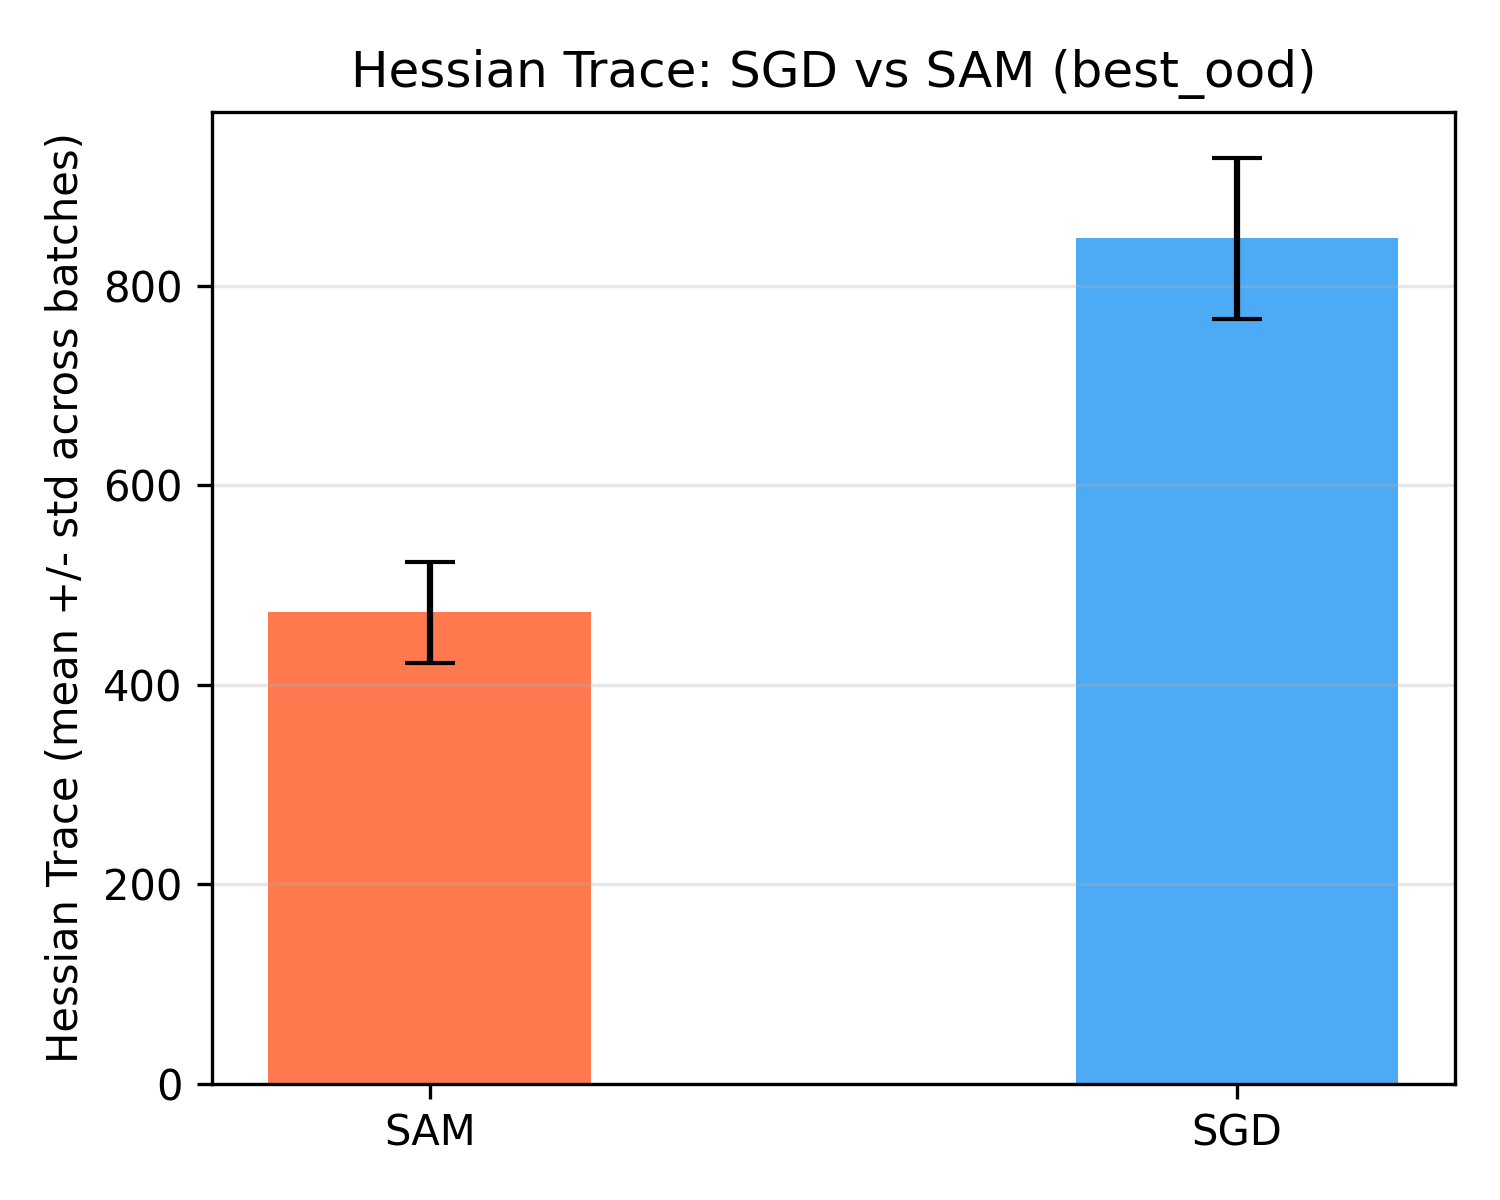

Saved best_ood_hessian_trace.png


In [28]:
# Figure 1: Hessian Trace bar chart
trace_agg = trace_df.groupby('model')['trace_mean'].agg(mean='mean', std='std').reset_index()

fig, ax = plt.subplots(figsize=(5, 4))
colors = {'SGD': '#2196F3', 'SAM': '#FF5722'}
for _, row in trace_agg.iterrows():
    ax.bar(row['model'], row['mean'], yerr=row['std'],
           color=colors[row['model']], alpha=0.8, capsize=6, width=0.4)
ax.set_ylabel('Hessian Trace (mean +/- std across batches)')
ax.set_title(f'Hessian Trace: SGD vs SAM ({CHECKPOINT_TAG})')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig_path = PART_C_DIR / f'{OUT_PREFIX}_hessian_trace.png'
plt.savefig(fig_path, dpi=300)
plt.close(fig)
display(IPImage(str(fig_path)))
print('Saved', fig_path.name)

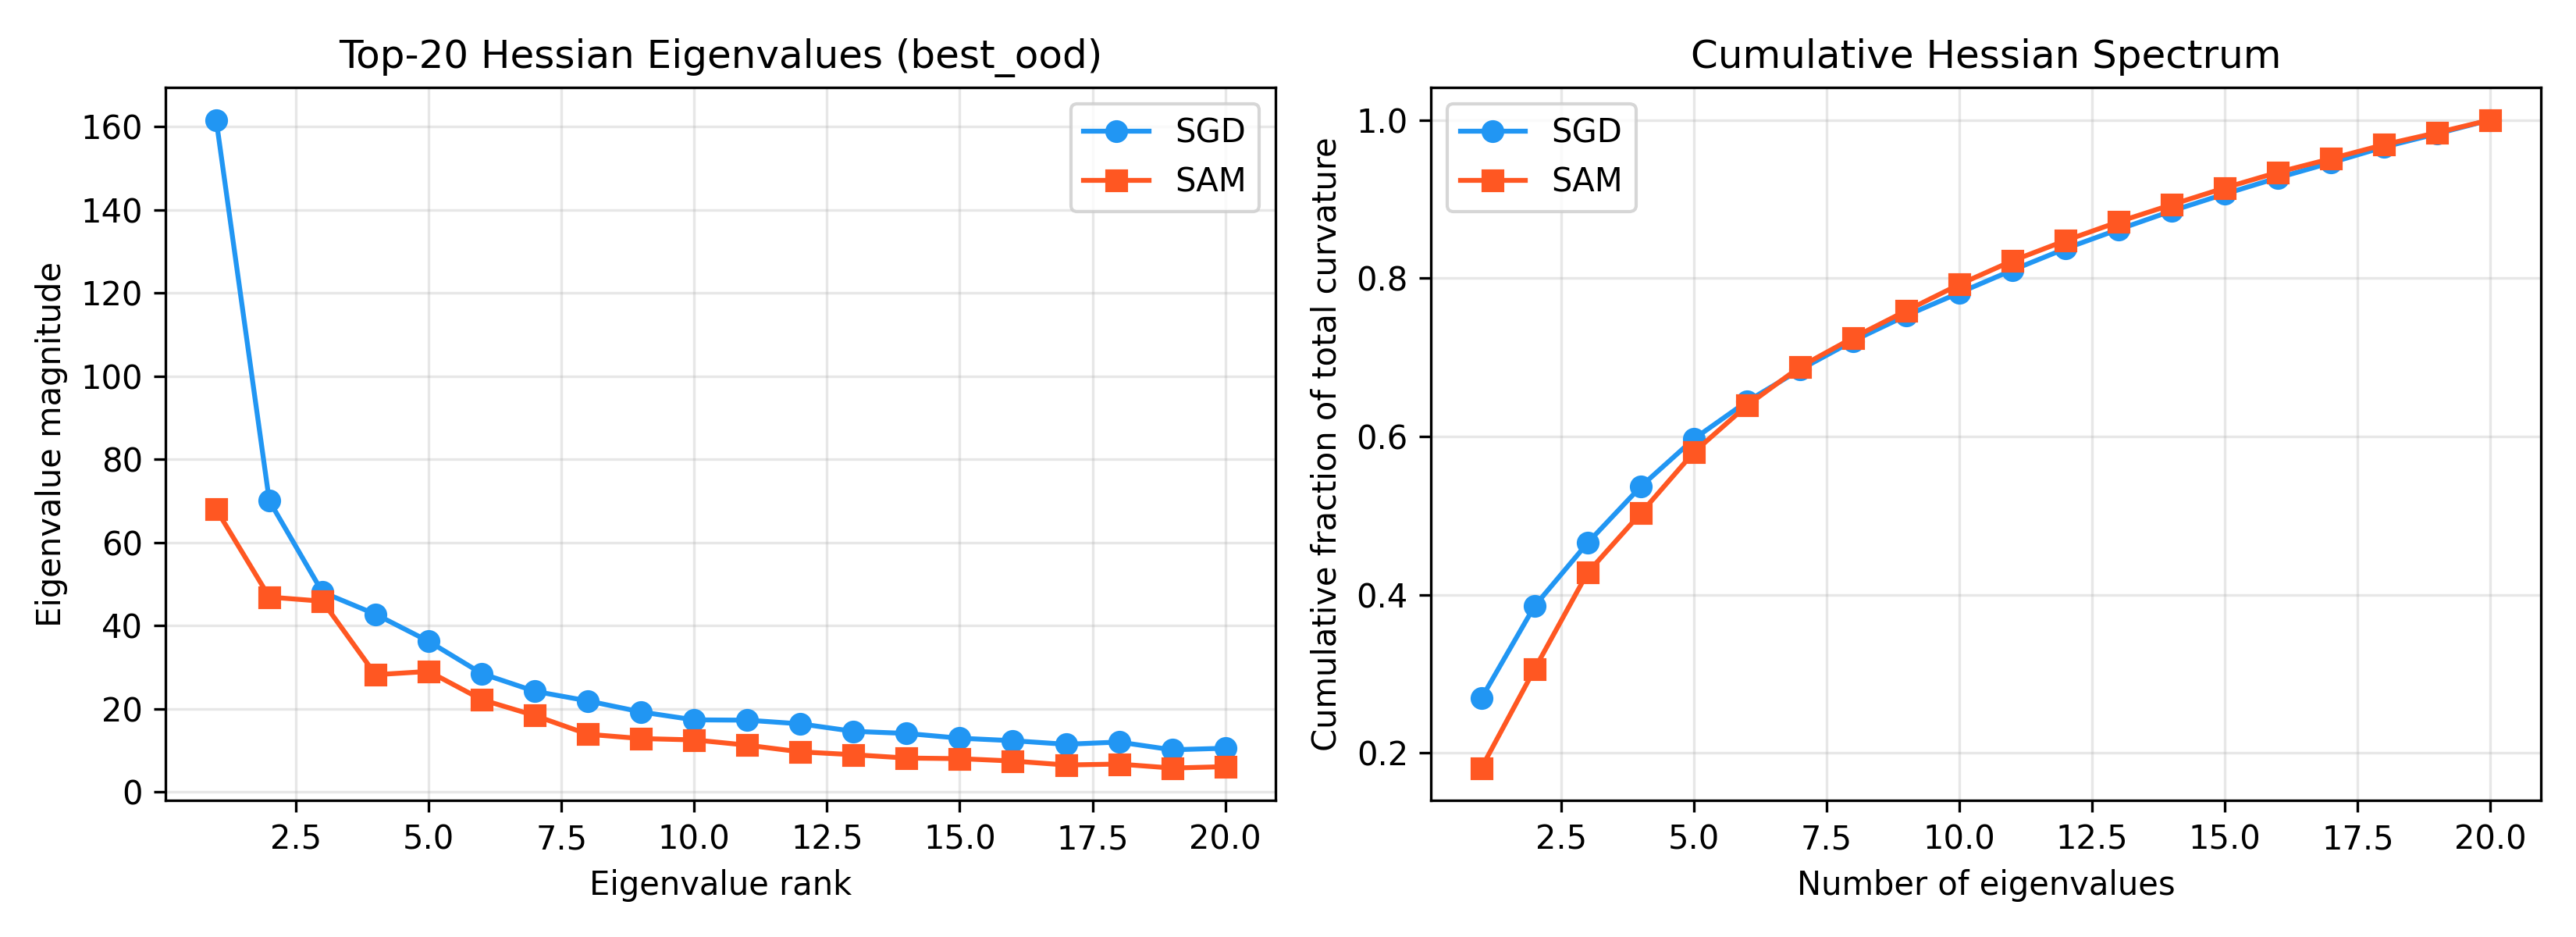

Saved best_ood_hessian_eigenvalue_spectrum.png


In [29]:
# Figure 2: Eigenvalue spectrum + cumulative
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
k_range = range(1, K + 1)

axes[0].plot(k_range, sgd_eigs, 'o-', label='SGD', color='#2196F3')
axes[0].plot(k_range, sam_eigs, 's-', label='SAM', color='#FF5722')
axes[0].set_xlabel('Eigenvalue rank')
axes[0].set_ylabel('Eigenvalue magnitude')
axes[0].set_title(f'Top-{K} Hessian Eigenvalues ({CHECKPOINT_TAG})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

def cum_explained(eigs):
    lams = np.array([max(l, 0) for l in eigs])
    return np.cumsum(lams) / (lams.sum() + 1e-12)

axes[1].plot(k_range, cum_explained(sgd_eigs), 'o-', label='SGD', color='#2196F3')
axes[1].plot(k_range, cum_explained(sam_eigs), 's-', label='SAM', color='#FF5722')
axes[1].set_xlabel('Number of eigenvalues')
axes[1].set_ylabel('Cumulative fraction of total curvature')
axes[1].set_title('Cumulative Hessian Spectrum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = PART_C_DIR / f'{OUT_PREFIX}_hessian_eigenvalue_spectrum.png'
plt.savefig(fig_path, dpi=300)
plt.close(fig)
display(IPImage(str(fig_path)))
print('Saved', fig_path.name)

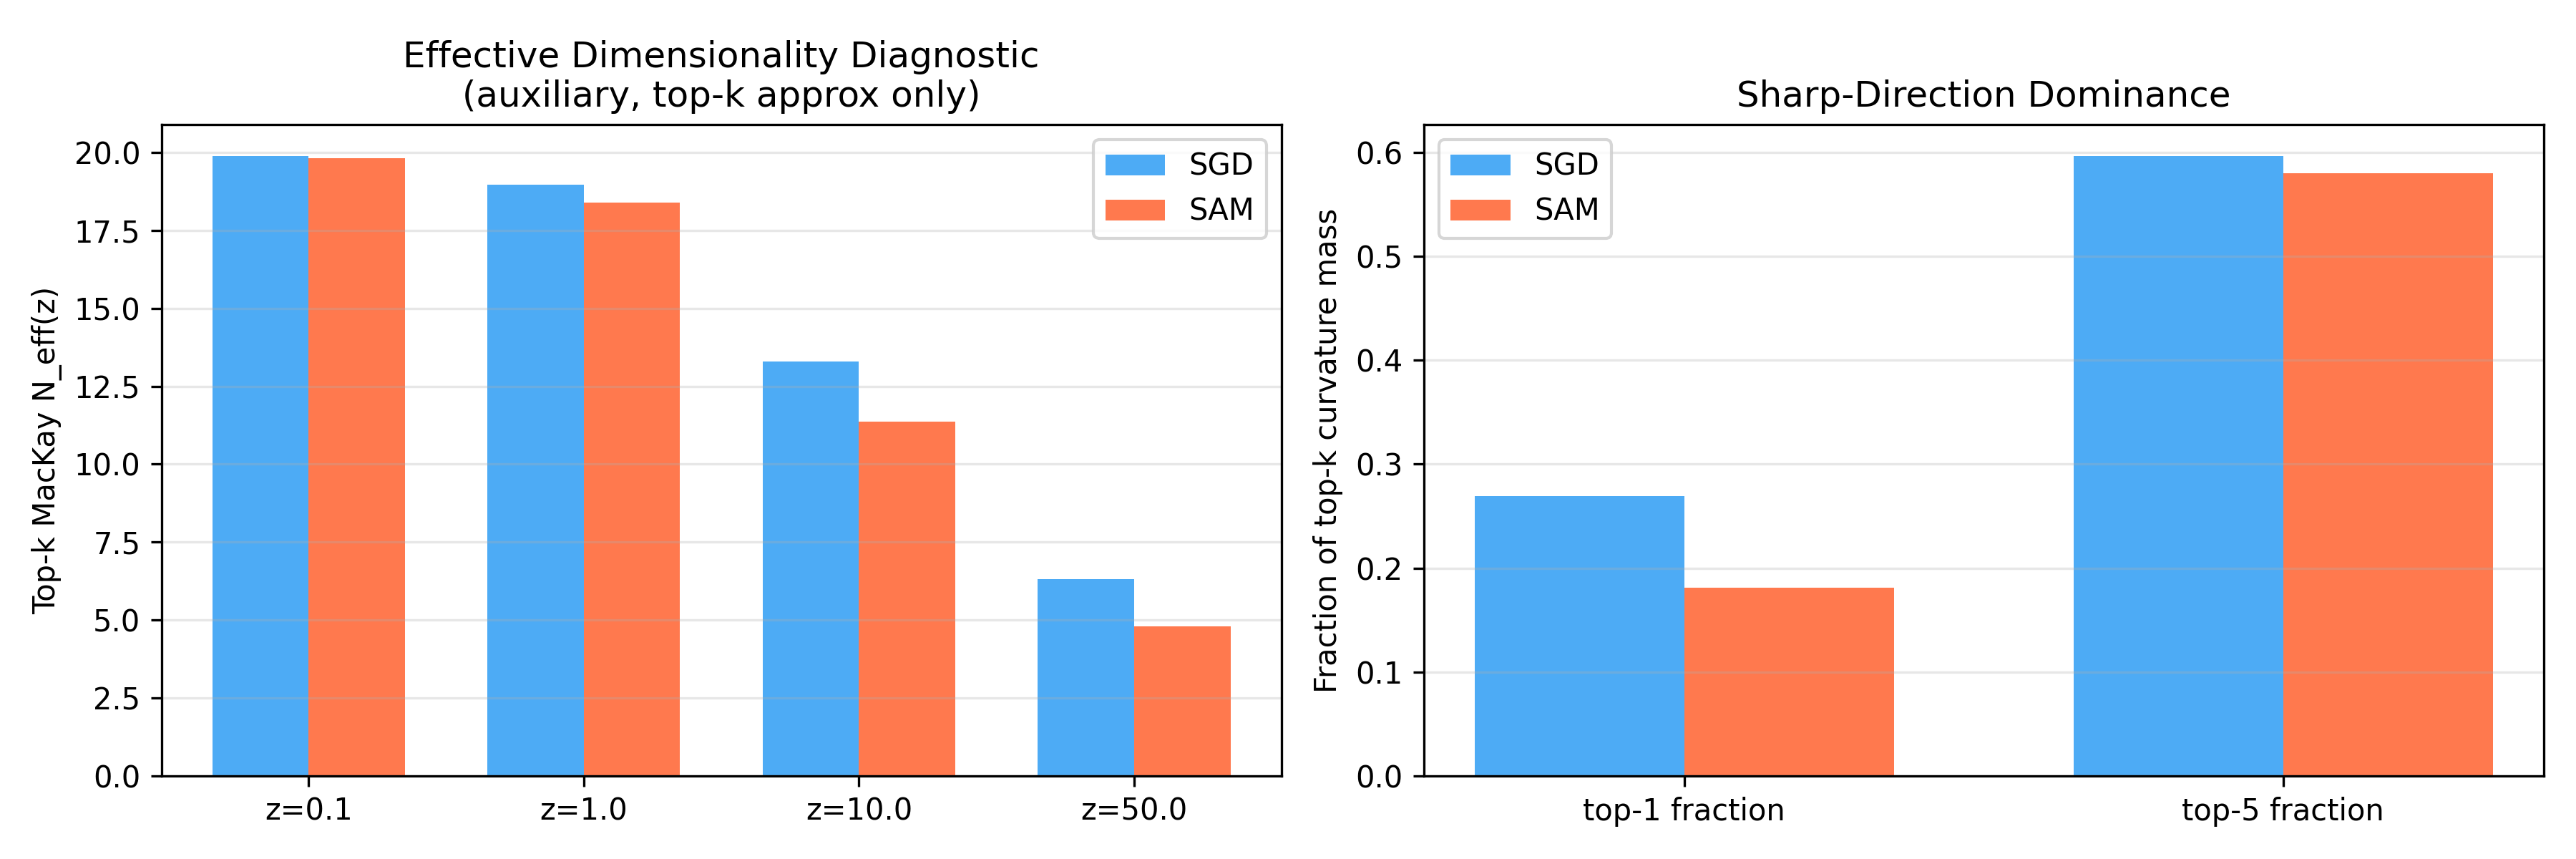

Saved best_ood_effective_dimensionality_and_concentration.png


In [30]:
# Figure 3: MacKay N_eff diagnostic and spectrum concentration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = range(len(z_values))
width = 0.35
axes[0].bar([i - width/2 for i in x], eff_dim_df['SGD_Neff_topk'], width,
            label='SGD', color='#2196F3', alpha=0.8)
axes[0].bar([i + width/2 for i in x], eff_dim_df['SAM_Neff_topk'], width,
            label='SAM', color='#FF5722', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f'z={z}' for z in z_values])
axes[0].set_ylabel('Top-k MacKay N_eff(z)')
axes[0].set_title('Effective Dimensionality Diagnostic\n(auxiliary, top-k approx only)')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

concentration_metrics = ['top1_fraction', 'top5_fraction']
metric_x = range(len(concentration_metrics))
axes[1].bar([i - width/2 for i in metric_x],
            [sgd_spec[m] for m in concentration_metrics], width,
            label='SGD', color='#2196F3', alpha=0.8)
axes[1].bar([i + width/2 for i in metric_x],
            [sam_spec[m] for m in concentration_metrics], width,
            label='SAM', color='#FF5722', alpha=0.8)
axes[1].set_xticks(list(metric_x))
axes[1].set_xticklabels(['top-1 fraction', 'top-5 fraction'])
axes[1].set_ylabel('Fraction of top-k curvature mass')
axes[1].set_title('Sharp-Direction Dominance')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
fig_path = PART_C_DIR / f'{OUT_PREFIX}_effective_dimensionality_and_concentration.png'
plt.savefig(fig_path, dpi=300)
plt.close(fig)
display(IPImage(str(fig_path)))
print('Saved', fig_path.name)

## 9. Save Results

In [31]:
sgd_trace_mean = trace_df[trace_df['model'] == 'SGD']['trace_mean'].mean()
sam_trace_mean = trace_df[trace_df['model'] == 'SAM']['trace_mean'].mean()
sgd_trace_std  = trace_df[trace_df['model'] == 'SGD']['trace_mean'].std()
sam_trace_std  = trace_df[trace_df['model'] == 'SAM']['trace_mean'].std()

eigenval_summary = pd.DataFrame({
    'checkpoint': [CHECKPOINT_TAG, CHECKPOINT_TAG],
    'model': ['SGD', 'SAM'],
    'hessian_trace_mean': [sgd_trace_mean, sam_trace_mean],
    'hessian_trace_std':  [sgd_trace_std,  sam_trace_std],
    'top1_eigenvalue': [sgd_spec['top1_eigenvalue'], sam_spec['top1_eigenvalue']],
    'sum_top_k':       [sgd_spec['sum_top_k'],       sam_spec['sum_top_k']],
    'top1_fraction':   [sgd_spec['top1_fraction'],   sam_spec['top1_fraction']],
    'top5_fraction':   [sgd_spec['top5_fraction'],   sam_spec['top5_fraction']],
    'Neff_z1_topk': [
        effective_dimensionality(sgd_eigs, z=1.0),
        effective_dimensionality(sam_eigs, z=1.0),
    ],
})

comparison_summary = pd.DataFrame([{
    'checkpoint': CHECKPOINT_TAG,
    'trace_reduction_pct':     100 * (sgd_trace_mean - sam_trace_mean) / (sgd_trace_mean + 1e-12),
    'top1_reduction_pct':      100 * (sgd_spec['top1_eigenvalue'] - sam_spec['top1_eigenvalue']) / (sgd_spec['top1_eigenvalue'] + 1e-12),
    'sum_topk_reduction_pct':  100 * (sgd_spec['sum_top_k'] - sam_spec['sum_top_k']) / (sgd_spec['sum_top_k'] + 1e-12),
    'top1_fraction_sgd_minus_sam': sgd_spec['top1_fraction'] - sam_spec['top1_fraction'],
    'top5_fraction_sgd_minus_sam': sgd_spec['top5_fraction'] - sam_spec['top5_fraction'],
    'Neff_z1_sgd_minus_sam_topk':  effective_dimensionality(sgd_eigs, z=1.0) - effective_dimensionality(sam_eigs, z=1.0),
}])

trace_df.to_csv(PART_C_DIR / f'{OUT_PREFIX}_hessian_trace_per_batch.csv', index=False)
eigenval_summary.to_csv(PART_C_DIR / f'{OUT_PREFIX}_eigenvalue_summary.csv', index=False)
eff_dim_df.to_csv(PART_C_DIR / f'{OUT_PREFIX}_effective_dimensionality.csv', index=False)
spectrum_summary_df.to_csv(PART_C_DIR / f'{OUT_PREFIX}_hessian_spectrum_concentration.csv', index=False)
metrics_df.to_csv(PART_C_DIR / f'{OUT_PREFIX}_checkpoint_metrics_used.csv', index=False)
comparison_summary.to_csv(PART_C_DIR / f'{OUT_PREFIX}_hessian_comparison_summary.csv', index=False)

print('Saved prefixed outputs to', PART_C_DIR)
print('\nFull summary:')
print(eigenval_summary.to_string(index=False))
print('\nSGD minus SAM / reduction summary:')
print(comparison_summary.to_string(index=False))

Saved prefixed outputs to /content/drive/MyDrive/Assignment2_SAM/part_c

Full summary:
checkpoint model  hessian_trace_mean  hessian_trace_std  top1_eigenvalue  sum_top_k  top1_fraction  top5_fraction  Neff_z1_topk
  best_ood   SGD          847.388593          80.303799       161.630168 600.767140       0.269040       0.596795     18.962404
  best_ood   SAM          472.550986          50.266996        67.943332 375.405248       0.180987       0.580012     18.393210

SGD minus SAM / reduction summary:
checkpoint  trace_reduction_pct  top1_reduction_pct  sum_topk_reduction_pct  top1_fraction_sgd_minus_sam  top5_fraction_sgd_minus_sam  Neff_z1_sgd_minus_sam_topk
  best_ood            44.234441           57.963706               37.512353                     0.088053                     0.016782                    0.569193


## 10. Interpretation

This section answers the Part C question: **does SAM's OOD advantage correspond to lower Hessian curvature magnitude and reduced sensitivity to sharp directions?**

All numbers below are from the `best_ood` checkpoint run on 5 fixed ID test batches (640 samples total).

---

### Performance Context (Part A, best_ood checkpoint)

| Optimizer | ID acc | Noise | Blur | Brightness | Avg OOD |
|-----------|--------|-------|------|------------|---------|
| SGD       | 84.8%  | 22.5% | 63.9% | 80.7%     | 55.7%   |
| SAM       | 86.2%  | 29.9% | 65.9% | 81.7%     | 59.2%   |

SAM improves average OOD accuracy by **+3.5 percentage points**. The gains are corruption-specific: SAM's largest advantage is on noise (+7.5 pp), with smaller gains on blur (+2.0 pp) and brightness (+1.0 pp). This pattern suggests that the flatness benefit may be most visible under noise corruption, although this should be interpreted as correlational rather than causal evidence.

---

### Evidence 1: Curvature Magnitude / Flatness (Main Finding)

All three curvature-magnitude metrics show a large, consistent reduction for SAM:

| Metric | SGD | SAM | Reduction |
|--------|-----|-----|-----------|
| Hessian trace (mean +/- std) | 847.4 +/- 80.3 | 472.6 +/- 50.3 | -44.2% |
| Top-1 eigenvalue | 161.6 | 67.9 | -58.0% |
| Sum of top-20 eigenvalues | 600.8 | 375.4 | -37.5% |

The trace reduction is consistent across all 5 batches (SGD is always higher), which confirms this is a robust property of the solution, not a batch artefact. SAM's top-1 eigenvalue, the worst-case local curvature direction, is more than halved. This is consistent with the sharpness-reduction mechanism described by Foret et al. (2021) and with Hessian-eigenvalue interpretations of sharpness used in recent Eigen-SAM work.

This is the cleanest version of the flat-minima claim, and it does not require any claim about the number of active parameter directions.

---

### Evidence 2: Sharp-Direction Dominance

| Metric | SGD | SAM | SGD - SAM |
|--------|-----|-----|-----------|
| top-1 fraction | 0.269 | 0.181 | +0.088 |
| top-5 fraction | 0.597 | 0.580 | +0.017 |

The top-1 fraction drops noticeably for SAM: the single sharpest direction accounts for 26.9% of total top-k curvature mass in SGD but only 18.1% in SAM. This suggests that SAM suppresses the dominant sharp direction rather than uniformly scaling all curvature down.

The top-5 fraction changes only slightly (0.597 to 0.580). This means the relative dominance of the five sharpest directions together is similar, but the single worst direction is less dominant in SAM. Together, this suggests SAM reduces the most extreme curvature direction while leaving the broader top-k spectrum shape broadly similar.

---

### Evidence 3: Effective Dimensionality (Auxiliary Diagnostic)

| z | SGD N_eff | SAM N_eff | SGD - SAM |
|---|-----------|-----------|-----------|
| 0.1 | 19.890 | 19.823 | 0.067 |
| 1.0 | 18.962 | 18.393 | 0.569 |
| 10.0 | 13.298 | 11.370 | 1.928 |
| 50.0 | 6.314 | 4.805 | 1.509 |

$N_{	ext{eff}}$ is consistently lower for SAM across all tested $z$ values, which provides secondary support that the top-k Hessian diagnostic is consistent with fewer strongly weighted high-curvature directions. However, the gap is small at low $z$ and grows at high $z$. Because this is only a top-k approximation, the result is $z$-sensitive, and the gap is modest compared with the curvature-magnitude reduction, we do not claim that lower effective dimensionality is the primary mechanism.

---

### Relation to the Broader Hypothesis

The original project hypothesis concerns over-squashing in GNNs, where curvature-aware graph rewiring may reduce topological bottlenecks. This Part C experiment does not directly test graph over-squashing because it uses ResNet18 on CIFAR-10 corruptions. The useful connection is:

> Curvature-aware training (SAM) can improve robustness, and Hessian diagnostics reveal that the improvement aligns with lower curvature magnitude and reduced sharp-direction sensitivity, not merely a uniform scaling of the spectrum.

This makes Part C a mechanistic support experiment for the broader geometry-aware argument, while keeping the claim scientifically modest.

---

### Conclusion

Part C provides three lines of evidence that SAM finds a geometrically different solution than SGD:

1. **SAM strongly reduces Hessian curvature magnitude** (-44.2% trace, -58.0% top eigenvalue, -37.5% top-k curvature mass). This is the primary and most robust finding, consistent across all 5 evaluation batches.
2. **SAM reduces dominance by the single sharpest direction** (top-1 fraction: 0.269 to 0.181), while the top-5 fraction is nearly unchanged, suggesting targeted suppression of the worst curvature direction.
3. **N_eff is consistently lower for SAM**, providing auxiliary support that the top-k Hessian diagnostic is consistent with fewer strongly weighted high-curvature directions, though the effect is small and z-sensitive.

Taken together, Part C supports a **curvature-magnitude explanation** of SAM's OOD advantage. The evidence does not support the stronger claim that lower effective dimensionality is the primary mechanism. The main story is that SAM reaches a substantially flatter region of the loss landscape, with an especially reduced dominant sharp direction, and this geometric difference correlates with improved OOD generalisation, particularly on noise corruption where the observed SAM advantage is largest.

Part B (gradient-direction sharpness proxy) and Part C (Hessian spectrum decomposition) are complementary: Part B is a coarse first-order proxy, while Part C decomposes the spectrum into curvature magnitude and sharp-direction structure.